In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sukhmandeepsinghbrar/daily-delhi-climate/DailyDelhiClimate.csv


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sukhmandeepsinghbrar/daily-delhi-climate/DailyDelhiClimate.csv')

In [4]:
df = df[['date','meantemp']]
df

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000
...,...,...
1571,2017-04-20,34.500000
1572,2017-04-21,34.250000
1573,2017-04-22,32.900000
1574,2017-04-23,32.875000


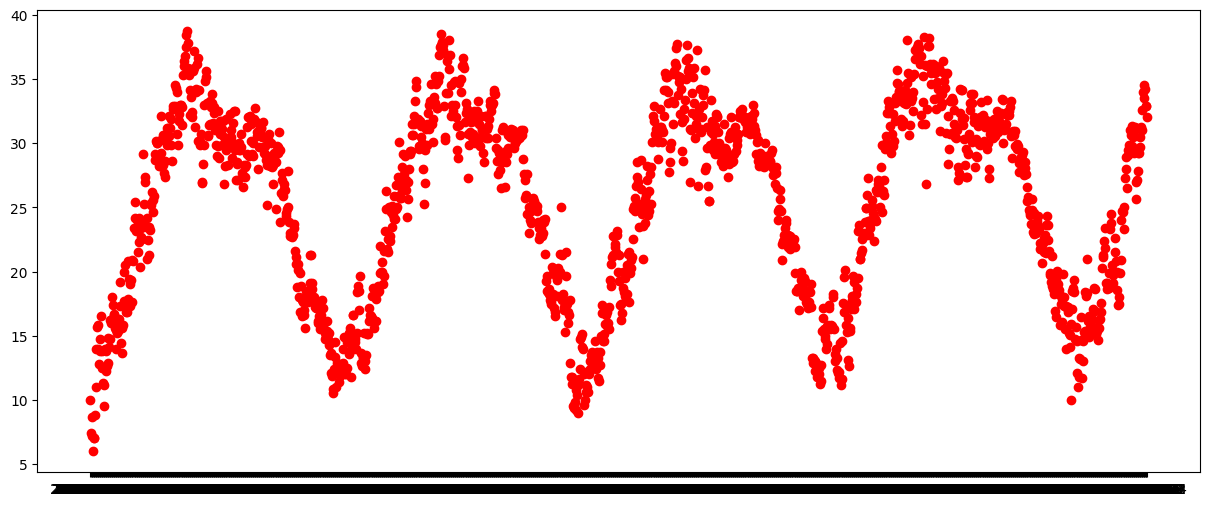

In [5]:
plt.figure(figsize=(15,6))
plt.scatter(df['date'],df['meantemp'],color='red') 
plt.show()

In [6]:
# beta = 0.1
x1 = df['meantemp'].ewm(alpha=0.9).mean()  # beta = 0.1
x2 = df['meantemp'].ewm(alpha=0.5).mean()  # beta = 0.5
x3 = df['meantemp'].ewm(alpha=0.1).mean()  # beta = 0.9
x4 = df['meantemp'].ewm(alpha=0.01).mean() # beta = 0.99

# beta = 1 - alpha 

In [7]:
x1

0       10.000000
1        7.636364
2        7.213213
3        8.521452
4        6.252123
          ...    
1571    34.403401
1572    34.265340
1573    33.036534
1574    32.891153
1575    32.089115
Name: meantemp, Length: 1576, dtype: float64

In [8]:
df['ewm'] = x1
df

,date,meantemp,ewm
0,2013-01-01,10.000000,10.000000
1,2013-01-02,7.400000,7.636364
2,2013-01-03,7.166667,7.213213
3,2013-01-04,8.666667,8.521452
4,2013-01-05,6.000000,6.252123
...,...,...,...
1571,2017-04-20,34.500000,34.403401
1572,2017-04-21,34.250000,34.265340
1573,2017-04-22,32.900000,33.036534
1574,2017-04-23,32.875000,32.891153


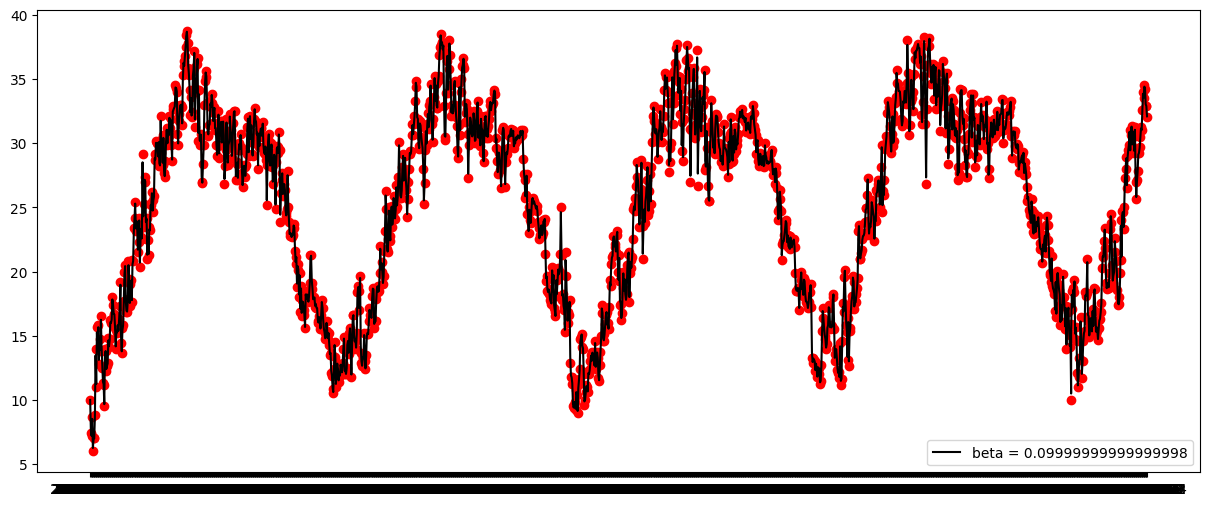

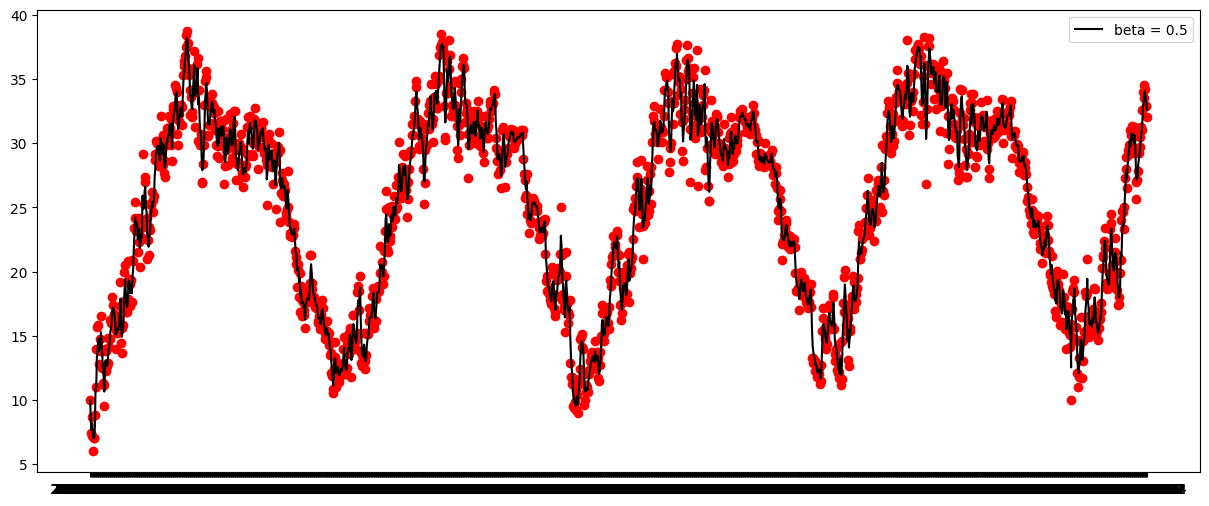

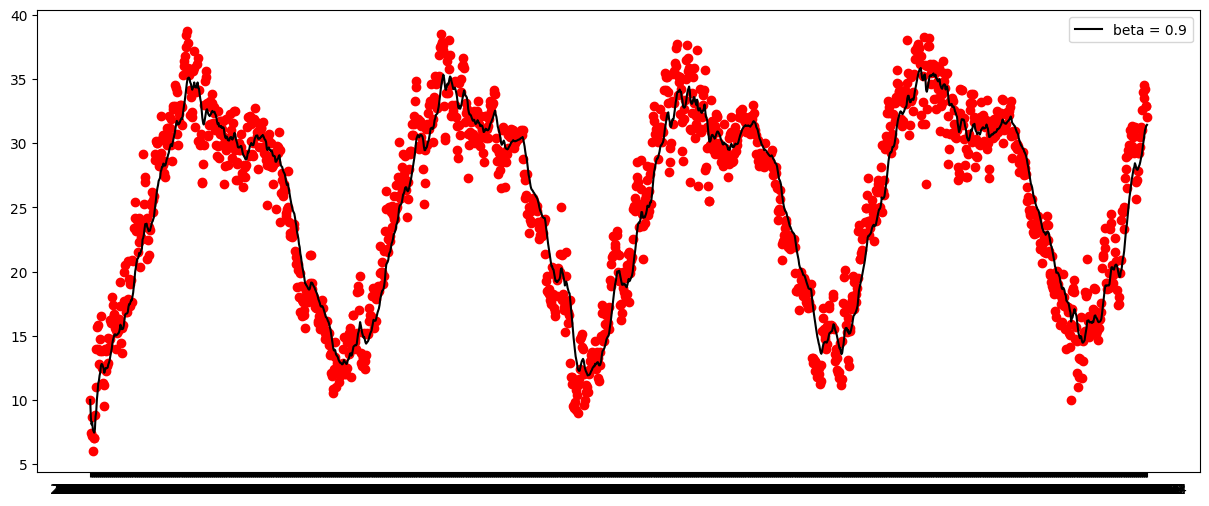

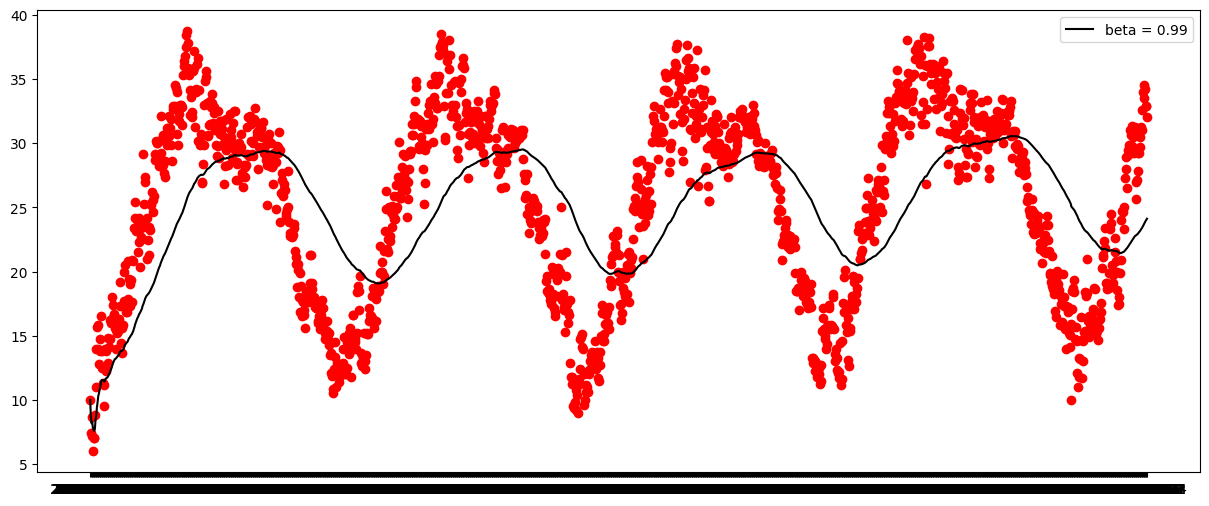

In [9]:
for i in [(x1,0.90),(x2,0.5),(x3,0.1),(x4,0.01)]:
    x,j = i
    plt.figure(figsize=(15,6))
    plt.scatter(df['date'],df['meantemp'],color='red') 
    plt.plot(df['date'],x,color='black',label=f'beta = {1-j}')
    plt.legend()
    plt.show()